Import All Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from scipy.signal import convolve2d

print("TensorFlow version:", tf.__version__)
print("All libraries loaded!")

TensorFlow version: 2.20.0
All libraries loaded!


Load and Display the Dataset

In [ ]:
# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("Dataset loaded!")
print("Training images:", X_train.shape)
print("Testing images: ", X_test.shape)
print("Pixel range:    ", X_train.min(), "to", X_train.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1095s 6us/step
Dataset loaded!
Training images: (50000, 32, 32, 3)
Testing images:  (10000, 32, 32, 3)
Pixel range:     0 to 255


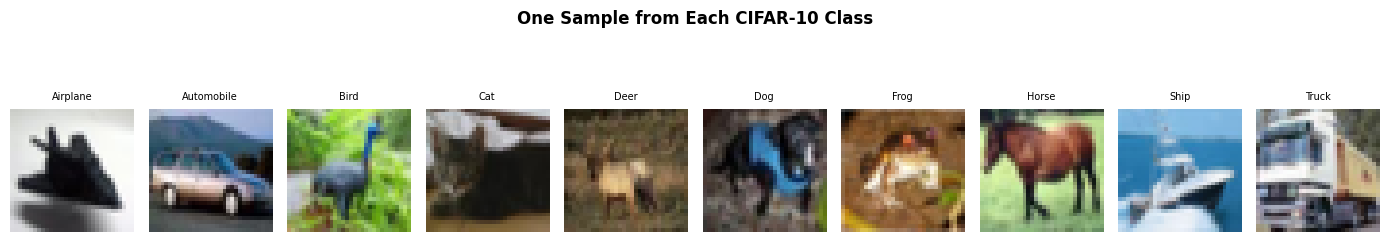

In [ ]:
# Display one image from each class
plt.figure(figsize=(14, 3))
for i, name in enumerate(class_names):
    # Find first image of this class
    idx = np.where(y_train.flatten() == i)[0][0]
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[idx])
    plt.title(name, fontsize=7)
    plt.axis('off')

plt.suptitle('One Sample from Each CIFAR-10 Class', fontweight='bold')
plt.tight_layout()
plt.show()

Image label : Frog
Image shape : (32, 32, 3)
Red channel values (first row):
[ 59  43  50  68  98 119 139 145 149 149 131 125 142 144 137 129 137 134
 124 139 139 133 136 139 152 163 168 159 158 158 152 148]


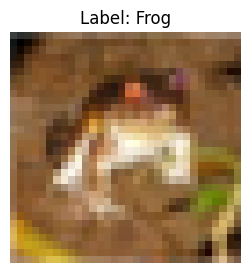

In [ ]:
# Look at one image in detail
sample = X_train[0]
label  = class_names[y_train[0][0]]

print(f"Image label : {label}")
print(f"Image shape : {sample.shape}")
print(f"Red channel values (first row):\n{sample[0, :, 0]}")

plt.figure(figsize=(3, 3))
plt.imshow(sample)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

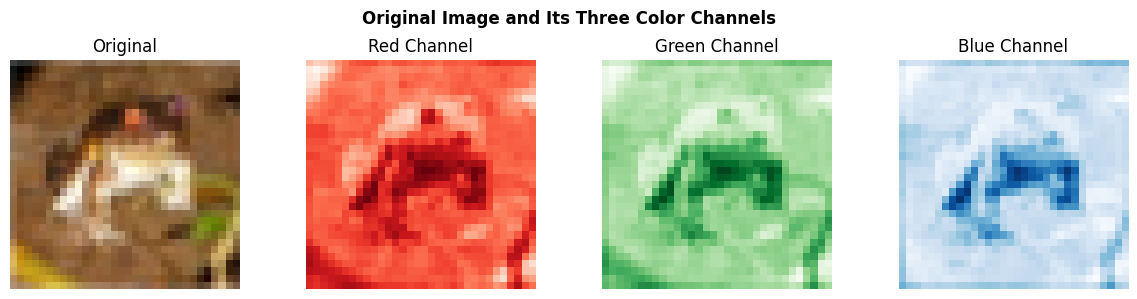

In [ ]:
# Show R, G, B channels separately
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(sample)
axes[0].set_title('Original')
axes[0].axis('off')

channel_names = ['Red Channel', 'Green Channel', 'Blue Channel']
colors        = ['Reds', 'Greens', 'Blues']

for i in range(3):
    axes[i+1].imshow(sample[:, :, i], cmap=colors[i])
    axes[i+1].set_title(channel_names[i])
    axes[i+1].axis('off')

plt.suptitle('Original Image and Its Three Color Channels',
             fontweight='bold')
plt.tight_layout()
plt.show()

Normalize the Images

In [ ]:
# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Flatten labels
y_train = y_train.flatten()
y_test  = y_test.flatten()

print("After normalization:")
print(f"  Pixel range: {X_train.min():.1f} to {X_train.max():.1f}")
print(f"  Data type  : {X_train.dtype}")
print(f"  Train shape: {X_train.shape}")

After normalization:
  Pixel range: 0.0 to 1.0
  Data type  : float32
  Train shape: (50000, 32, 32, 3)


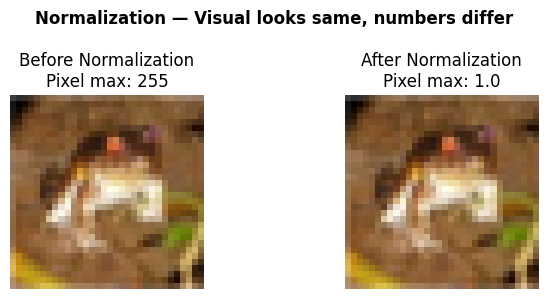

Before — sample pixel: [59 62 63]
After  — sample pixel: [0.23137255 0.24313726 0.24705882]


In [ ]:
# Compare before and after — visually they look identical
# but the numbers underneath are completely different
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Note: we already normalized X_train so we reload one image
original = (X_train[0] * 255).astype(int)   # reverse to show original

axes[0].imshow(original)
axes[0].set_title(f'Before Normalization\nPixel max: 255')
axes[0].axis('off')

axes[1].imshow(X_train[0])
axes[1].set_title(f'After Normalization\nPixel max: 1.0')
axes[1].axis('off')

plt.suptitle('Normalization — Visual looks same, numbers differ',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("Before — sample pixel:", original[0, 0])
print("After  — sample pixel:", X_train[0][0, 0])

Working image: Horse
Shape: (32, 32, 3)


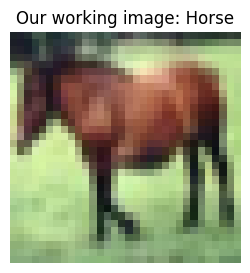

In [ ]:
# Pick one image to work with for Tasks 2, 3, 4
# We'll use a horse image — lots of texture and edges
horse_idx = np.where(y_train == 7)[0][0]
sample_img = X_train[horse_idx]

print(f"Working image: {class_names[y_train[horse_idx]]}")
print(f"Shape: {sample_img.shape}")

plt.figure(figsize=(3, 3))
plt.imshow(sample_img)
plt.title(f"Our working image: {class_names[y_train[horse_idx]]}")
plt.axis('off')
plt.show()

Implement Convolution Operation

Color image shape: (32, 32, 3)
Grayscale shape:   (32, 32)


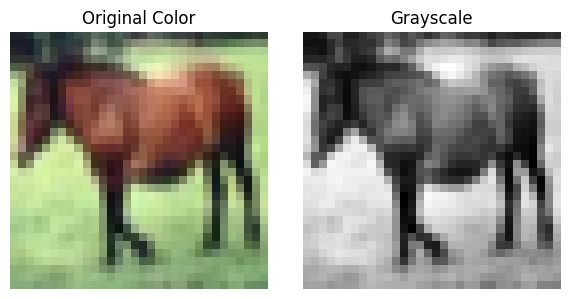

In [ ]:
# Convert image to grayscale for manual convolution
# (easier to visualize — one channel instead of three)
def to_grayscale(img):
    return np.dot(img, [0.299, 0.587, 0.114])

gray_img = to_grayscale(sample_img)

print("Color image shape:", sample_img.shape)
print("Grayscale shape:  ", gray_img.shape)

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title('Original Color')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Manual convolution using scipy
def apply_convolution(image, kernel):
    return convolve2d(image, kernel, mode='same', boundary='fill')

# Define a 3×3 identity kernel (does nothing — outputs same image)
kernel_3x3 = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
])

# Define a 5×5 identity kernel
kernel_5x5 = np.zeros((5, 5))
kernel_5x5[2, 2] = 1  # center = 1, everything else = 0

# Apply both
output_3x3 = apply_convolution(gray_img, kernel_3x3)
output_5x5 = apply_convolution(gray_img, kernel_5x5)

print("Original shape:      ", gray_img.shape)
print("After 3×3 conv shape:", output_3x3.shape)
print("After 5×5 conv shape:", output_5x5.shape)

Original shape:       (32, 32)
After 3×3 conv shape: (32, 32)
After 5×5 conv shape: (32, 32)


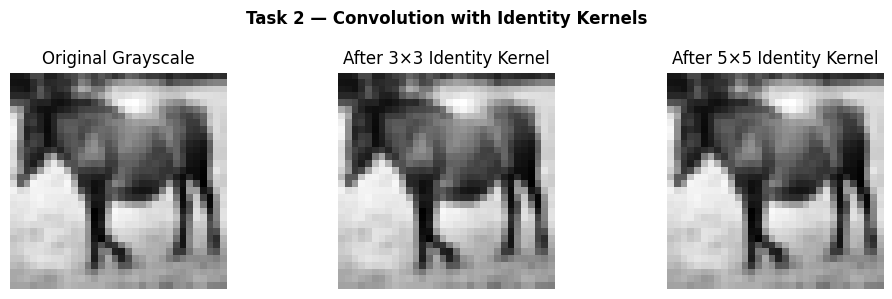


Identity kernel explanation:
  Center value = 1, everything else = 0
  At each position: only the center pixel contributes
  Result: output is identical to input
  Purpose: confirms our convolution function works correctly



In [ ]:
# Compare original vs 3×3 vs 5×5 identity convolution
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(output_3x3, cmap='gray')
axes[1].set_title('After 3×3 Identity Kernel')
axes[1].axis('off')

axes[2].imshow(output_5x5, cmap='gray')
axes[2].set_title('After 5×5 Identity Kernel')
axes[2].axis('off')

plt.suptitle('Task 2 — Convolution with Identity Kernels',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Identity kernel explanation:
  Center value = 1, everything else = 0
  At each position: only the center pixel contributes
  Result: output is identical to input
  Purpose: confirms our convolution function works correctly
""")

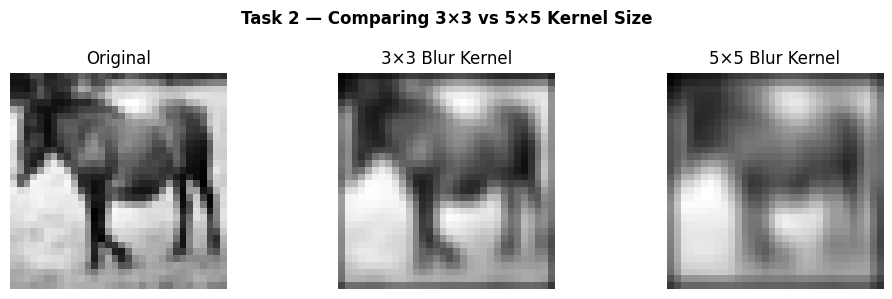


Kernel size observation:
  3×3 blur → slight blurring
  5×5 blur → stronger blurring
  Larger kernels capture wider context but lose finer details



In [ ]:
# Average blur — 3×3 vs 5×5 to compare kernel sizes
kernel_blur_3 = np.ones((3, 3)) / 9    # each value = 1/9
kernel_blur_5 = np.ones((5, 5)) / 25   # each value = 1/25

blur_3 = apply_convolution(gray_img, kernel_blur_3)
blur_5 = apply_convolution(gray_img, kernel_blur_5)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(blur_3, cmap='gray')
axes[1].set_title('3×3 Blur Kernel')
axes[1].axis('off')

axes[2].imshow(blur_5, cmap='gray')
axes[2].set_title('5×5 Blur Kernel')
axes[2].axis('off')

plt.suptitle('Task 2 — Comparing 3×3 vs 5×5 Kernel Size',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Kernel size observation:
  3×3 blur → slight blurring
  5×5 blur → stronger blurring
  Larger kernels capture wider context but lose finer details
""")

Apply Different Convolution Filters

In [ ]:
# Define all four filters
filters = {

    'Edge Detection': np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ]),

    'Sharpening': np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ]),

    'Blur': np.array([
        [1/9, 1/9, 1/9],
        [1/9, 1/9, 1/9],
        [1/9, 1/9, 1/9]
    ]),

    'Emboss': np.array([
        [-2, -1,  0],
        [-1,  1,  1],
        [ 0,  1,  2]
    ])
}

print("All four filters defined!")
for name, kernel in filters.items():
    print(f"\n{name} kernel:")
    print(kernel)

All four filters defined!

Edge Detection kernel:
[[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]

Sharpening kernel:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]

Blur kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

Emboss kernel:
[[-2 -1  0]
 [-1  1  1]
 [ 0  1  2]]


In [ ]:
# Apply all four filters and store results
filter_outputs = {}
for name, kernel in filters.items():
    result = apply_convolution(gray_img, kernel)
    # Clip to valid display range
    result = np.clip(result, 0, 1)
    filter_outputs[name] = result

print("All filters applied!")

All filters applied!


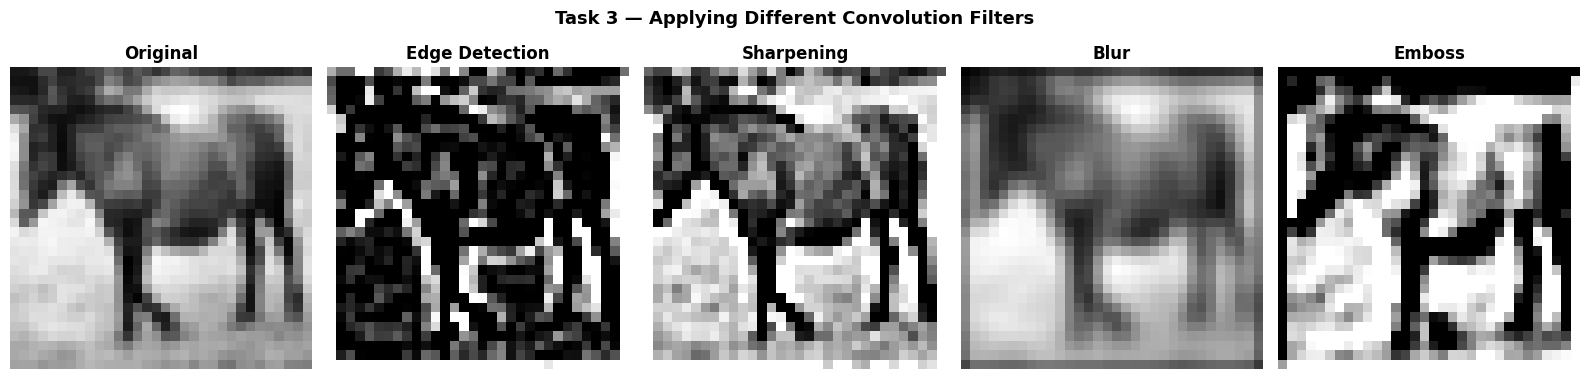

In [ ]:
# Display original + all four filter outputs
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

# Original
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

# Four filters
for i, (name, output) in enumerate(filter_outputs.items()):
    axes[i+1].imshow(output, cmap='gray')
    axes[i+1].set_title(name, fontweight='bold')
    axes[i+1].axis('off')

plt.suptitle('Task 3 — Applying Different Convolution Filters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

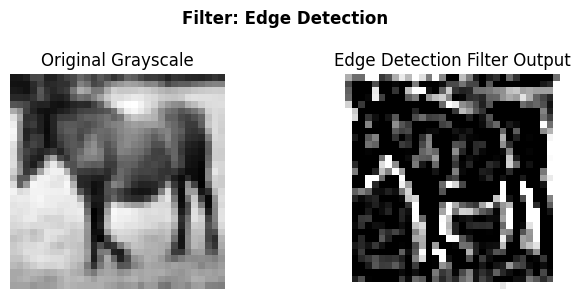

  → Highlights boundaries where pixel intensity changes sharply. Flat regions become black. Edges become bright white.



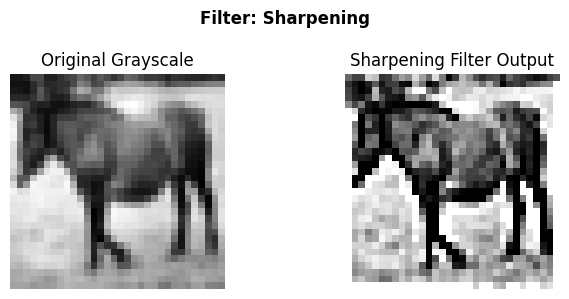

  → Enhances fine details and makes edges crisper. Overall structure preserved but boundaries are more defined.



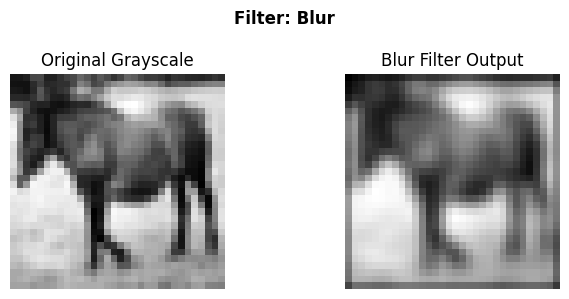

  → Averages neighbouring pixels. Removes noise and fine detail. Image appears smooth and soft.



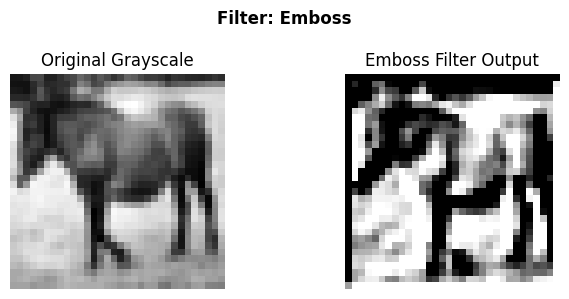

  → Creates a 3D raised effect by emphasizing directional differences. Highlights textures and contours.



In [ ]:
# Zoomed side by side — original vs each filter
for name, output in filter_outputs.items():
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))

    axes[0].imshow(gray_img, cmap='gray')
    axes[0].set_title('Original Grayscale')
    axes[0].axis('off')

    axes[1].imshow(output, cmap='gray')
    axes[1].set_title(f'{name} Filter Output')
    axes[1].axis('off')

    plt.suptitle(f'Filter: {name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Explanation per filter
    explanations = {
        'Edge Detection': 'Highlights boundaries where pixel intensity changes sharply. Flat regions become black. Edges become bright white.',
        'Sharpening'    : 'Enhances fine details and makes edges crisper. Overall structure preserved but boundaries are more defined.',
        'Blur'          : 'Averages neighbouring pixels. Removes noise and fine detail. Image appears smooth and soft.',
        'Emboss'        : 'Creates a 3D raised effect by emphasizing directional differences. Highlights textures and contours.'
    }
    print(f"  → {explanations[name]}\n")

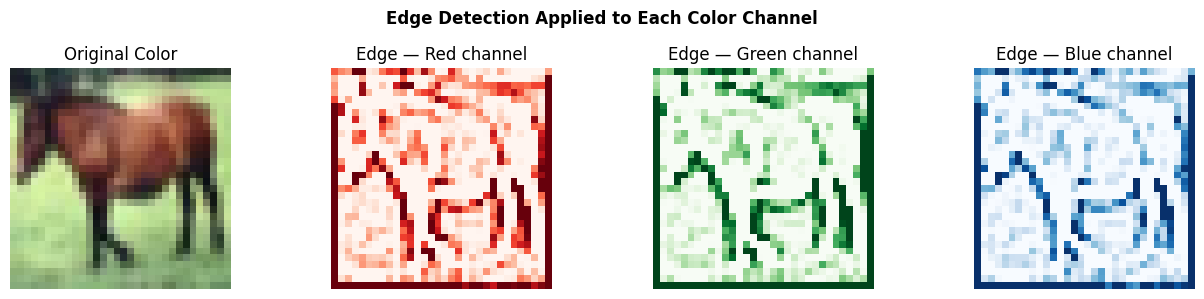

In [ ]:
# Apply edge detection to each color channel separately
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
edge_kernel = filters['Edge Detection']

axes[0].imshow(sample_img)
axes[0].set_title('Original Color')
axes[0].axis('off')

channel_names = ['Red', 'Green', 'Blue']
cmaps         = ['Reds', 'Greens', 'Blues']

for i in range(3):
    channel_edge = apply_convolution(sample_img[:,:,i], edge_kernel)
    channel_edge = np.clip(channel_edge, 0, 1)
    axes[i+1].imshow(channel_edge, cmap=cmaps[i])
    axes[i+1].set_title(f'Edge — {channel_names[i]} channel')
    axes[i+1].axis('off')

plt.suptitle('Edge Detection Applied to Each Color Channel',
             fontweight='bold')
plt.tight_layout()
plt.show()

Build a CNN and Visualize Feature Maps

In [ ]:
# Build a simple CNN for feature map extraction
cnn_model = keras.Sequential([

    # First Conv layer — 32 filters, 3×3 kernel
    layers.Conv2D(32, (3,3), activation='relu',
                  padding='same',
                  input_shape=(32, 32, 3),
                  name='conv_1'),
    layers.MaxPooling2D((2,2), name='pool_1'),

    # Second Conv layer — 64 filters, 3×3 kernel
    layers.Conv2D(64, (3,3), activation='relu',
                  padding='same',
                  name='conv_2'),
    layers.MaxPooling2D((2,2), name='pool_2'),

    # Third Conv layer — 128 filters
    layers.Conv2D(128, (3,3), activation='relu',
                  padding='same',
                  name='conv_3'),
    layers.MaxPooling2D((2,2), name='pool_2b'),

    # Classification head
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Feature_Map_CNN')

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Feature_Map_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2b (MaxPooling2D)          │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and train for just 5 epochs
# We don't need high accuracy — just trained weights
# to produce meaningful feature maps

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training for 5 epochs to get meaningful feature maps...")
cnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)
print("Training done!")

Training for 5 epochs to get meaningful feature maps...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 139ms/step - accuracy: 0.4429 - loss: 1.5214 - val_accuracy: 0.5742 - val_loss: 1.1847
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 136ms/step - accuracy: 0.6176 - loss: 1.0909 - val_accuracy: 0.6550 - val_loss: 0.9842
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 167s 172ms/step - accuracy: 0.6830 - loss: 0.9096 - val_accuracy: 0.7068 - val_loss: 0.8502
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 120s 141ms/step - accuracy: 0.7233 - loss: 0.7956 - val_accuracy: 0.7070 - val_loss: 0.8653
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 139ms/step - accuracy: 0.7515 - loss: 0.7158 - val_accuracy: 0.7280 - val_loss: 0.7968
Training done!


In [ ]:
# Fix — pass a dummy image through the model first
# This tells Keras exactly what the input looks like

dummy = tf.zeros((1, 32, 32, 3))
_ = cnn_model(dummy)

# Now build the feature extractor
feature_extractor = keras.Model(
    inputs=cnn_model.inputs,
    outputs=[
        cnn_model.get_layer('conv_1').output,
        cnn_model.get_layer('conv_2').output,
        cnn_model.get_layer('conv_3').output
    ]
)

print("Feature extractor ready!")

Feature extractor ready!


In [ ]:
# Pick one test image
test_img   = X_test[0:1]
true_label = class_names[y_test[0]]

print(f"Extracting feature maps for: {true_label}")

feat_map_1, feat_map_2, feat_map_3 = feature_extractor.predict(test_img)

print(f"Layer 1 shape: {feat_map_1.shape}")
print(f"Layer 2 shape: {feat_map_2.shape}")
print(f"Layer 3 shape: {feat_map_3.shape}")

Extracting feature maps for: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Layer 1 shape: (1, 32, 32, 32)
Layer 2 shape: (1, 16, 16, 64)
Layer 3 shape: (1, 8, 8, 128)


Layer 1 feature maps:

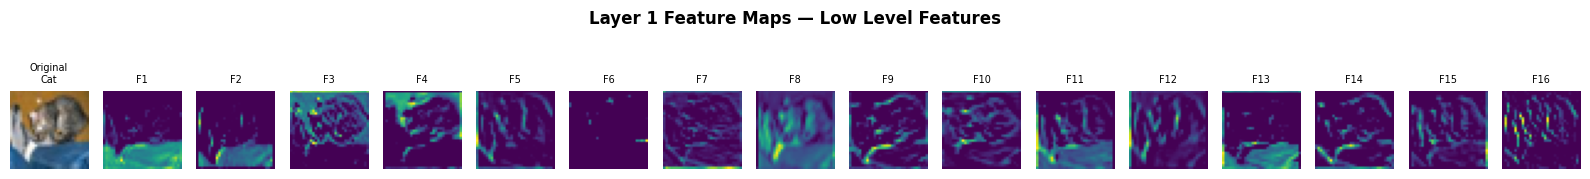

In [ ]:
fig = plt.figure(figsize=(16, 6))

ax = fig.add_subplot(3, 17, 1)
ax.imshow(test_img[0])
ax.set_title('Original\n' + true_label, fontsize=7)
ax.axis('off')

for i in range(16):
    ax = fig.add_subplot(3, 17, i+2)
    ax.imshow(feat_map_1[0, :, :, i], cmap='viridis')
    ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

plt.suptitle('Layer 1 Feature Maps — Low Level Features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Layer 2 feature maps:

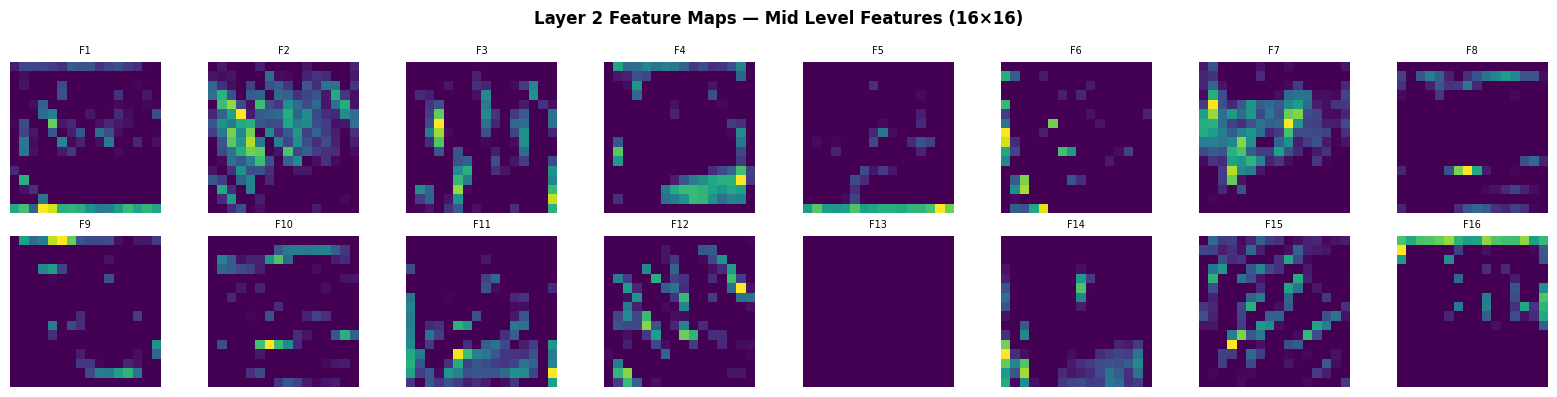

In [ ]:
fig = plt.figure(figsize=(16, 4))

for i in range(16):
    ax = fig.add_subplot(2, 8, i+1)
    ax.imshow(feat_map_2[0, :, :, i], cmap='viridis')
    ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

plt.suptitle('Layer 2 Feature Maps — Mid Level Features (16×16)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Layer 3 feature maps

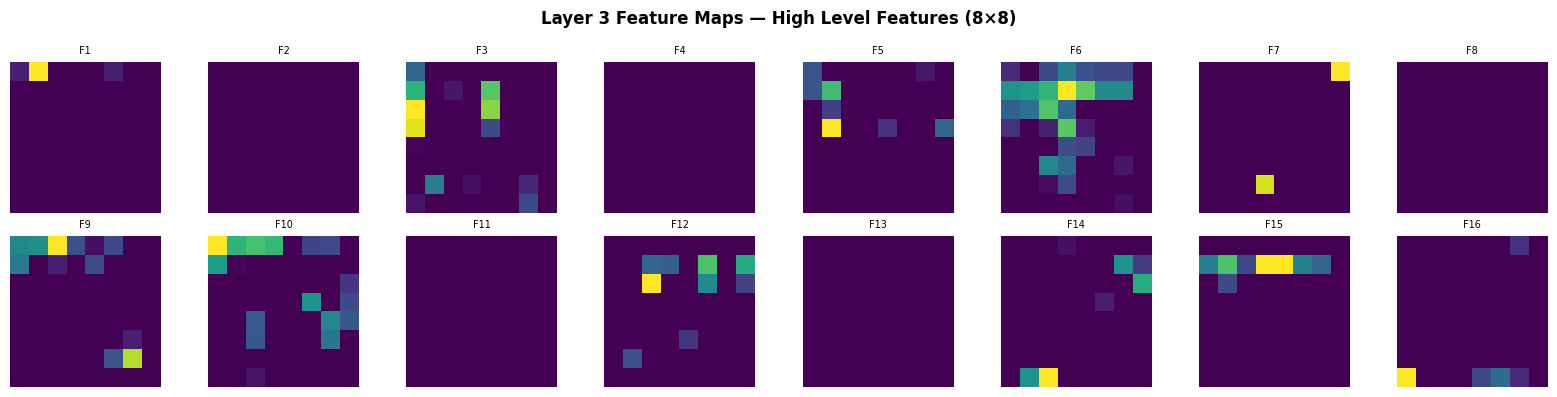

In [ ]:
fig = plt.figure(figsize=(16, 4))

for i in range(16):
    ax = fig.add_subplot(2, 8, i+1)
    ax.imshow(feat_map_3[0, :, :, i], cmap='viridis')
    ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

plt.suptitle('Layer 3 Feature Maps — High Level Features (8×8)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

All three layers side by side

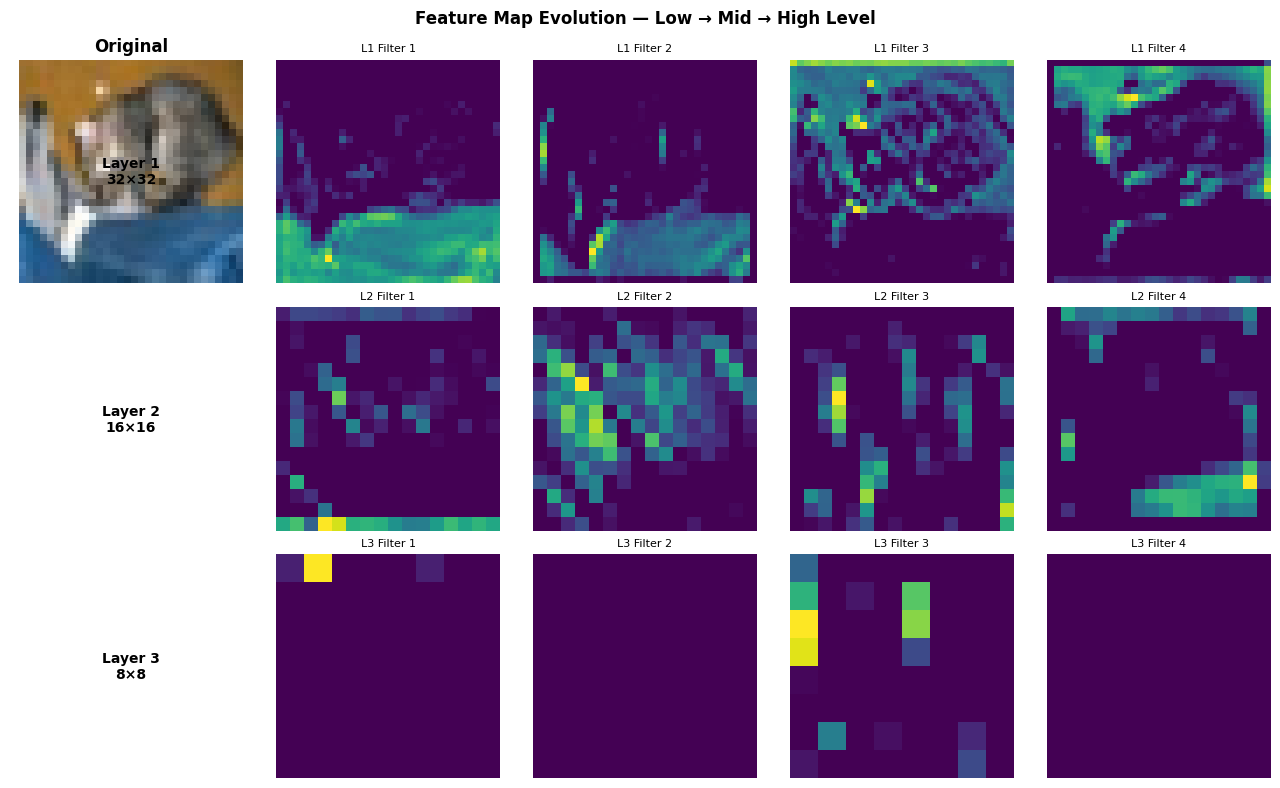

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(13, 8))

axes[0,0].imshow(test_img[0])
axes[0,0].set_title('Original', fontweight='bold')
axes[0,0].axis('off')
axes[1,0].axis('off')
axes[2,0].axis('off')

for col, f_idx in enumerate([0, 1, 2, 3]):
    axes[0, col+1].imshow(feat_map_1[0,:,:,f_idx], cmap='viridis')
    axes[0, col+1].set_title(f'L1 Filter {f_idx+1}', fontsize=8)
    axes[0, col+1].axis('off')

    axes[1, col+1].imshow(feat_map_2[0,:,:,f_idx], cmap='viridis')
    axes[1, col+1].set_title(f'L2 Filter {f_idx+1}', fontsize=8)
    axes[1, col+1].axis('off')

    axes[2, col+1].imshow(feat_map_3[0,:,:,f_idx], cmap='viridis')
    axes[2, col+1].set_title(f'L3 Filter {f_idx+1}', fontsize=8)
    axes[2, col+1].axis('off')

for row, label in enumerate(['Layer 1\n32×32', 'Layer 2\n16×16', 'Layer 3\n8×8']):
    axes[row, 0].text(0.5, 0.5, label,
                      ha='center', va='center',
                      fontsize=10, fontweight='bold',
                      transform=axes[row,0].transAxes)

plt.suptitle('Feature Map Evolution — Low → Mid → High Level',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Experimental Analysis

In [ ]:
# Helper function for experiments
def conv_experiment(kernel_size, num_filters, padding, stride):
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(
        filters     = num_filters,
        kernel_size = kernel_size,
        strides     = stride,
        padding     = padding,
        activation  = 'relu'
    )(inputs)
    exp_model = keras.Model(inputs, x)
    output = exp_model.predict(test_img, verbose=0)
    return output, exp_model

print("Experiment function ready!")

Experiment function ready!


Experiment 1 — Kernel Size

In [ ]:
kernel_sizes = [3, 5, 7]

print("Kernel size comparison:")
for k in kernel_sizes:
    output, _ = conv_experiment(k, 16, 'same', 1)
    print(f"  Kernel {k}×{k} → output shape: {output.shape}")

Kernel size comparison:
  Kernel 3×3 → output shape: (1, 32, 32, 16)
  Kernel 5×5 → output shape: (1, 32, 32, 16)
  Kernel 7×7 → output shape: (1, 32, 32, 16)


All same size because padding=same

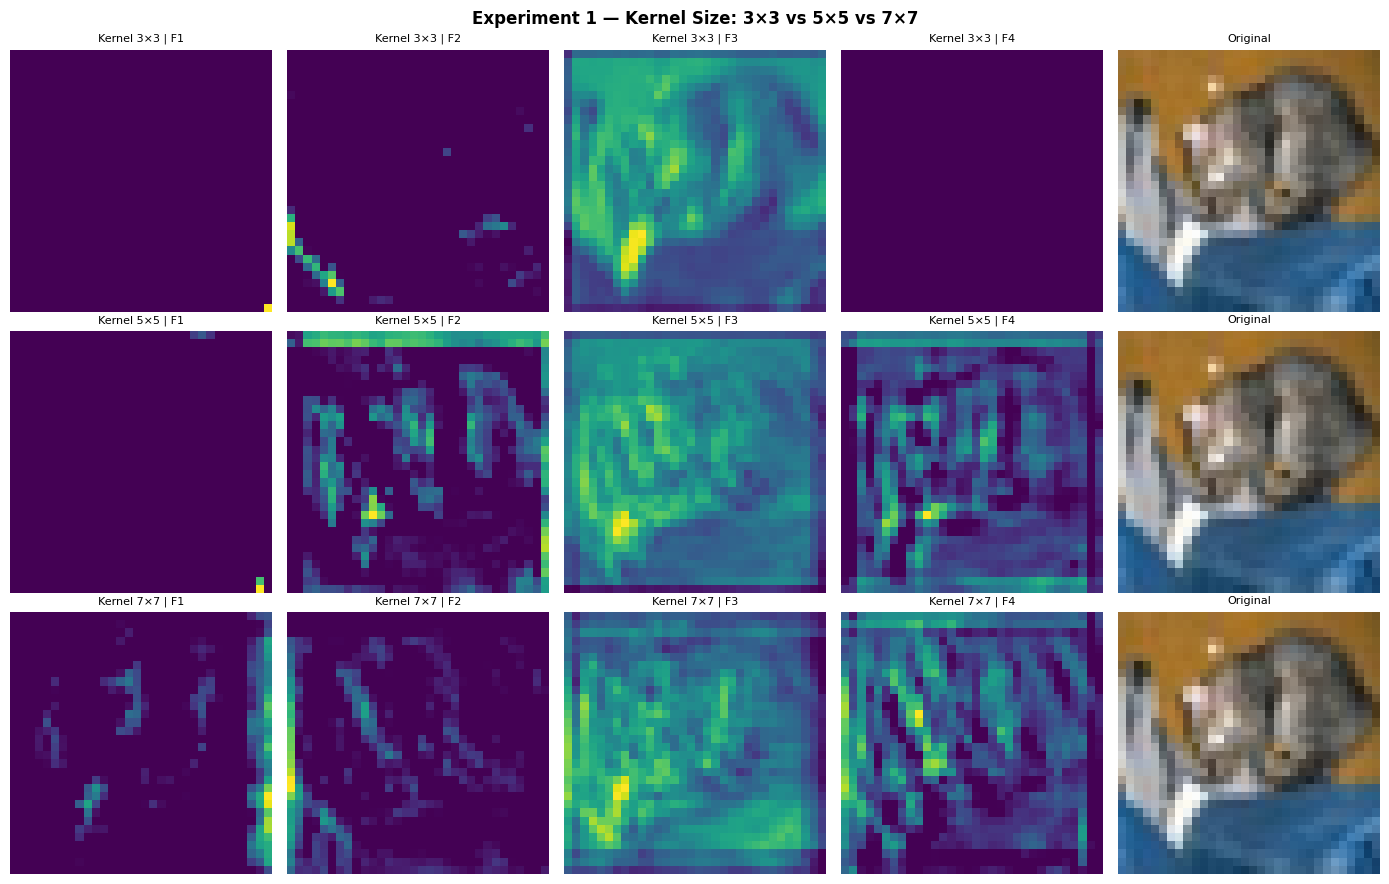


Observations:
  3×3 → sharp fine details, precise edges
  5×5 → slightly smoother, broader patterns
  7×7 → widest context, smoothest output
  Larger kernel = sees more pixels at once = broader features



In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(14, 9))

for row, k in enumerate(kernel_sizes):
    output, _ = conv_experiment(k, 16, 'same', 1)
    for col in range(4):
        axes[row, col].imshow(output[0,:,:,col], cmap='viridis')
        axes[row, col].set_title(f'Kernel {k}×{k} | F{col+1}',
                                  fontsize=8)
        axes[row, col].axis('off')
    axes[row, 4].imshow(test_img[0])
    axes[row, 4].set_title('Original', fontsize=8)
    axes[row, 4].axis('off')

plt.suptitle('Experiment 1 — Kernel Size: 3×3 vs 5×5 vs 7×7',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Observations:
  3×3 → sharp fine details, precise edges
  5×5 → slightly smoother, broader patterns
  7×7 → widest context, smoothest output
  Larger kernel = sees more pixels at once = broader features
""")

Experiment 2 — Number of Filters

In [ ]:
filter_counts = [8, 32, 64]

print("Filter count comparison:")
for f in filter_counts:
    output, model = conv_experiment(3, f, 'same', 1)
    params = model.count_params()
    print(f"  {f:>3} filters → output: {output.shape} "
          f"| parameters: {params:,}")

Filter count comparison:
    8 filters → output: (1, 32, 32, 8) | parameters: 224
   32 filters → output: (1, 32, 32, 32) | parameters: 896
   64 filters → output: (1, 32, 32, 64) | parameters: 1,792


visualize

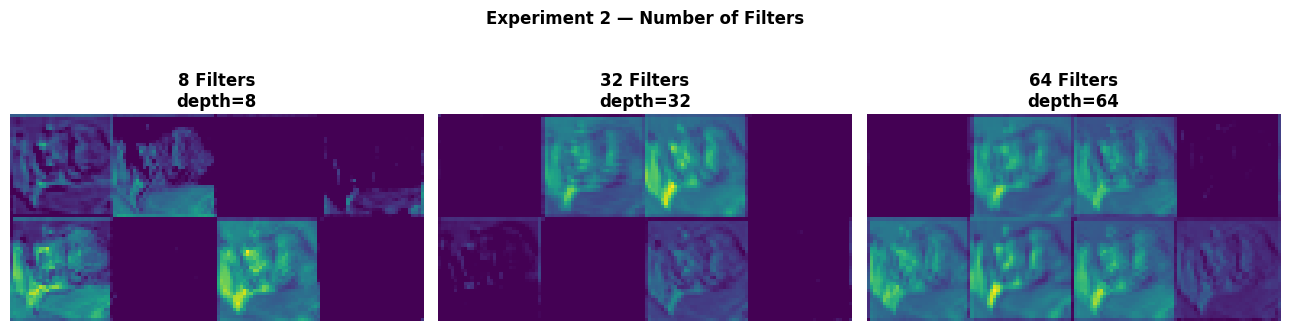


Observations:
  8  filters → limited variety, misses some patterns
  32 filters → good balance of features detected
  64 filters → richer, more diverse feature detection
  More filters = more patterns learned = more parameters



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for col, f in enumerate(filter_counts):
    output, _ = conv_experiment(3, f, 'same', 1)
    num_show  = min(f, 8)
    grid      = [output[0,:,:,i] for i in range(num_show)]
    row1      = np.hstack(grid[:4])
    row2      = np.hstack(grid[4:8]) if num_show > 4 \
                else np.zeros_like(row1)
    combined  = np.vstack([row1, row2])

    axes[col].imshow(combined, cmap='viridis')
    axes[col].set_title(f'{f} Filters\ndepth={f}',
                         fontweight='bold')
    axes[col].axis('off')

plt.suptitle('Experiment 2 — Number of Filters',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Observations:
  8  filters → limited variety, misses some patterns
  32 filters → good balance of features detected
  64 filters → richer, more diverse feature detection
  More filters = more patterns learned = more parameters
""")

Padding

In [ ]:
paddings = ['same', 'valid']

print("Padding comparison:")
for p in paddings:
    output, _ = conv_experiment(3, 16, p, 1)
    print(f"  padding={p:>5} → output shape: {output.shape}")

Padding comparison:
  padding= same → output shape: (1, 32, 32, 16)
  padding=valid → output shape: (1, 30, 30, 16)


visualize

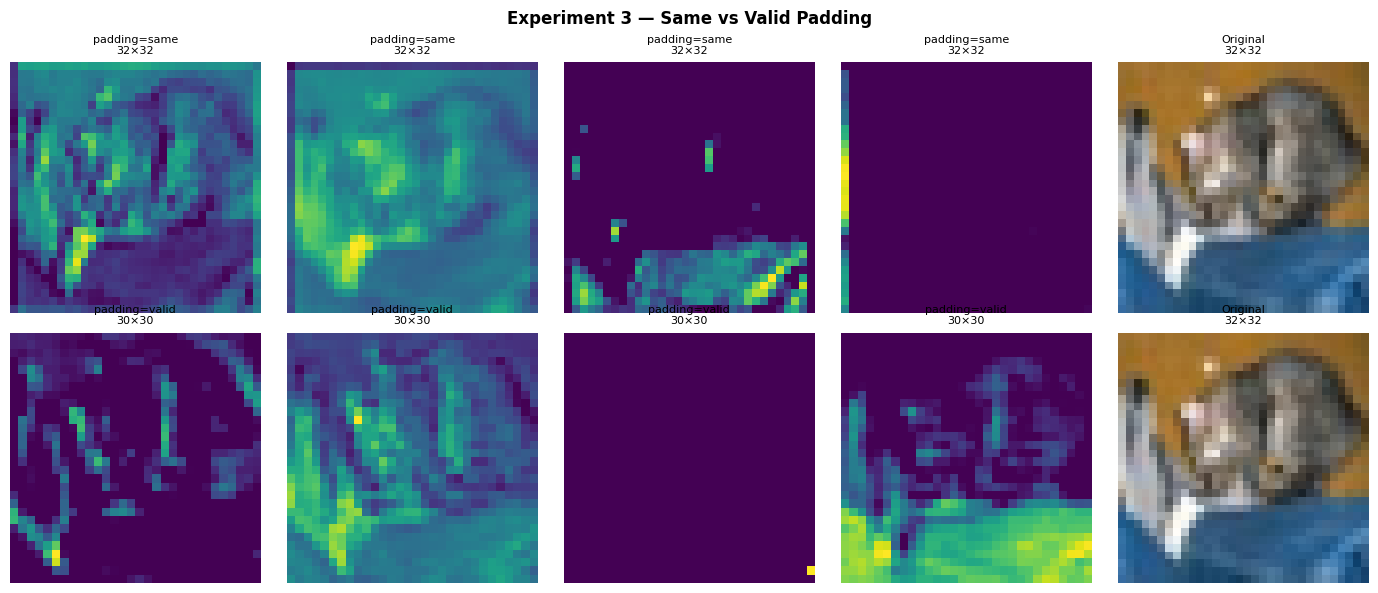


Observations:
  same  → adds zeros around border → output stays 32×32
  valid → no padding → output shrinks to 30×30
  Formula: output = input - kernel + 1 = 32 - 3 + 1 = 30
  same padding preferred — preserves spatial dimensions



In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for row, p in enumerate(paddings):
    output, _ = conv_experiment(3, 16, p, 1)
    for col in range(4):
        axes[row, col].imshow(output[0,:,:,col], cmap='viridis')
        axes[row, col].set_title(
            f'padding={p}\n{output.shape[1]}×{output.shape[2]}',
            fontsize=8)
        axes[row, col].axis('off')
    axes[row, 4].imshow(test_img[0])
    axes[row, 4].set_title('Original\n32×32', fontsize=8)
    axes[row, 4].axis('off')

plt.suptitle('Experiment 3 — Same vs Valid Padding',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Observations:
  same  → adds zeros around border → output stays 32×32
  valid → no padding → output shrinks to 30×30
  Formula: output = input - kernel + 1 = 32 - 3 + 1 = 30
  same padding preferred — preserves spatial dimensions
""")